# 3. Bayesian Regime-Switching Model

**Model:**
$$\text{spread}_t = (1 - s_t)\, c_0 + s_t\, c_1 + \phi\, \text{spread}_{t-1} + \varepsilon_t, \quad \varepsilon_t \sim N(0, \sigma^2)$$

$$z_t = w_t' \alpha + \eta_t, \quad \eta_t \sim N(0,1), \quad s_t = \mathbb{1}[z_t > 0]$$

**Identification:** $c_0 < c_1$ (regime 0 = corn-stressed / low spread, regime 1 = soy-stressed / high spread)

**Gibbs sampler** (5 blocks, all conjugate):
1. Draw $s_t$ from Bernoulli (switching regression, Paap slide 28)
2. Draw $z_t$ from truncated Normal (Albert-Chib, Paap slide 14)
3. Draw $\alpha$ from Normal (probit regression, Paap slide 15)
4. Draw $(c_0, c_1, \phi)$ from Normal with $c_0 < c_1$ constraint
5. Draw $\sigma^2$ from IG-2 (Paap slide 29)

In [81]:
%load_ext autoreload
%autoreload 2

import sys
sys.path.insert(0, '..')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_acf
from scipy.stats import norm
import json
with open('../data/selected_weather_features.json') as f:
    weather_cols = json.load(f)
print(f'{len(weather_cols)} weather features loaded.')

from src.features import compute_hedge_ratio, compute_kalman_hedge
from src.regime import prepare_regime_data, gibbs_regime_switching

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
24 weather features loaded.


## 1. Load data and compute spreads

In [82]:
df = pd.read_csv('../data/full_dataset.csv', index_col='date', parse_dates=True)
df = compute_hedge_ratio(df, 'close_corn', 'close_soybean')     # adds ols_spread, ols_hedge_ratio
df = compute_kalman_hedge(df, 'close_corn', 'close_soybean')    # adds kf_spread, kf_hedge_ratio, ...

print(f'Full sample: {df.index[0].date()} to {df.index[-1].date()}, {len(df)} trading days')
df.head()

Window:          504 trading days
Valid rows:      3148 / 3652
Hedge ratio:     -0.0992 to 1.3937
Intercept:       -5.8013 to 23.9495
Spread mean:     0.0989
Converged in 8 iteration(s)
  phi      = 0.996003  (half-life = 250 trading days)
  sigma2_s = 0.023109
  delta    = 1.0e-05  (hyperparameter — tune via CV)
  R        = 1.0e-06  (numerical floor)
Hedge ratio:      0.2550 to 0.7351
Spread level std: 1.7017
Innovation z std: 1.1113 (ideal ~ 1.0)
Level z std:      1.2242
Full sample: 2011-09-19 to 2026-03-27, 3652 trading days


,close_corn,high_corn,low_corn,open_corn,volume_corn,close_soybean,high_soybean,low_soybean,open_soybean,volume_soybean,...,wind_speed_10m_max_rio_grande_sul_roll30d_max,hedge_ratio,intercept,spread,kf_hedge_ratio,kf_intercept,kf_spread,kf_innovation,kf_z_score,kf_level_z
date,,,,,,,,,,,,,,,,,,,,,
2011-09-19,45.650002,45.919998,45.000000,45.459999,114300,24.549999,24.549999,24.549999,24.549999,100,...,26.552288,NaN,NaN,NaN,0.537768,0.000827,0.000084,1.724998,0.011946,NaN
2011-09-20,45.540001,46.720001,45.369999,46.110001,117200,25.080000,25.080000,24.660000,24.990000,1200,...,26.552288,NaN,NaN,NaN,0.537273,0.324052,0.288520,0.589156,2.811236,NaN
2011-09-21,44.799999,46.040001,44.750000,45.900002,83300,24.340000,25.110001,24.340000,24.959999,4400,...,26.552288,NaN,NaN,NaN,0.562364,-0.878857,0.024964,-0.341250,-1.591518,NaN
2011-09-22,42.990002,44.669998,42.650002,43.959999,352500,24.000000,24.000000,24.000000,24.000000,100,...,26.552288,NaN,NaN,NaN,0.461177,3.515265,0.658709,0.677969,2.817640,NaN
2011-09-23,42.450001,43.389999,42.400002,42.990002,158800,23.000000,24.430000,23.000000,24.430000,300,...,26.552288,NaN,NaN,NaN,0.488993,2.034801,0.207452,-0.748319,-3.642390,NaN


## 2. Select weather variables

Hand-pick 5-8 agronomically motivated variables.  
Adjust the list below — each name must match a column in `df`.

In [83]:
weather_cols = [
    'soil_moisture_28_to_100cm_mean_central_illinois_roll30d_min',   # Corn Belt deep soil drought
    'soil_moisture_0_to_100cm_mean_parana_roll30d_min',              # Brazilian soy drought
    'precipitation_sum_central_indiana_roll30d_sum',                  # Corn Belt rainfall
    'temperature_2m_mean_mato_grosso_roll30d_mean',                  # Brazilian heat stress
    'vapour_pressure_deficit_max_mato_grosso_roll30d_mean',          # Brazilian evaporative demand
]

# Verify all columns exist
missing = [c for c in weather_cols if c not in df.columns]
if missing:
    print(f'WARNING — columns not found: {missing}')
    print(f'Available weather columns (first 20):')
    weather_candidates = [c for c in df.columns if any(loc in c for loc in ['iowa', 'illinois', 'indiana', 'mato', 'parana', 'rio'])]
    for c in weather_candidates[:20]:
        print(f'  {c}')
else:
    print(f'Selected {len(weather_cols)} weather variables — all found.')

Selected 5 weather variables — all found.


## 3. Prepare data

In [84]:
# --- Choose spread ---
spread_col = 'spread'   # or 'kf_spread' for Kalman version

y, y_lag, W, col_names = prepare_regime_data(
    df, spread_col, weather_cols, standardize_weather=True
)
print(f'Effective sample: T = {len(y)}')
print(f'Probit regressors ({W.shape[1]}): {col_names}')

Effective sample: T = 3147
Probit regressors (6): ['intercept', 'soil_moisture_28_to_100cm_mean_central_illinois_roll30d_min', 'soil_moisture_0_to_100cm_mean_parana_roll30d_min', 'precipitation_sum_central_indiana_roll30d_sum', 'temperature_2m_mean_mato_grosso_roll30d_mean', 'vapour_pressure_deficit_max_mato_grosso_roll30d_mean']


## 4. Prior configuration

**Defaults are diffuse / flat priors.**  
To experiment with informative priors, set the arrays below and pass them to the sampler.

### 4a. Probit prior (alpha)
- `None` = flat prior $p(\alpha) \propto 1$  
- Informative: $\alpha \sim N(a_0, A_0)$, e.g. $a_0 = 0$, $A_0 = I$

In [88]:
# --- Probit prior ---
# Option A: flat (default)
#prior_alpha_mean = None
#prior_alpha_var  = None

# Option B: weakly informative (uncomment to use)
k_alpha = W.shape[1] + 1   # +1 for delta (Markov persistence)
prior_alpha_mean = np.zeros(k_alpha)
prior_alpha_var  = np.eye(k_alpha)

### 4b. Theta prior (c0, c1, phi)
- `None` = diffuse prior $p(\theta, \sigma^2) \propto \sigma^{-2}$  
- Informative: $\theta | \sigma^2 \sim N(b_0, \sigma^2 B_0)$

In [89]:
# --- Theta prior ---
# Option A: diffuse (default)
prior_theta_mean = None
prior_theta_var  = None

# Option B: weakly informative (uncomment to use)
# prior_theta_mean = np.array([0.0, 0.0, 0.95])           # center phi near unit root
# prior_theta_var  = np.diag([100.0, 100.0, 0.04])        # SD: c's = 10, phi = 0.2

## 5. Run Gibbs sampler

In [90]:
# --- Sampler settings ---
nos = 10000     # valid draws to keep
nob = 100000      # burn-in
nod = 2         # thinning
seed = 42

print(f'Total iterations: {nos * nod + nob}')
print(f'Running Gibbs sampler ({spread_col})...')

draws = gibbs_regime_switching(
    y, y_lag, W,
    nos=nos, nob=nob, nod=nod,
    prior_alpha_mean=prior_alpha_mean,
    prior_alpha_var=prior_alpha_var,
    prior_theta_mean=prior_theta_mean,
    prior_theta_var=prior_theta_var,
    seed=seed,
)
print('Done.')

Total iterations: 120000
Running Gibbs sampler (spread)...
  iteration 0 / 120000
  iteration 5000 / 120000
  iteration 10000 / 120000
  iteration 15000 / 120000
  iteration 20000 / 120000
  iteration 25000 / 120000
  iteration 30000 / 120000
  iteration 35000 / 120000
  iteration 40000 / 120000
  iteration 45000 / 120000
  iteration 50000 / 120000
  iteration 55000 / 120000
  iteration 60000 / 120000
  iteration 65000 / 120000
  iteration 70000 / 120000
  iteration 75000 / 120000
  iteration 80000 / 120000
  iteration 85000 / 120000
  iteration 90000 / 120000
  iteration 95000 / 120000
  iteration 100000 / 120000
  iteration 105000 / 120000
  iteration 110000 / 120000
  iteration 115000 / 120000
Done.


## 6. Convergence diagnostics

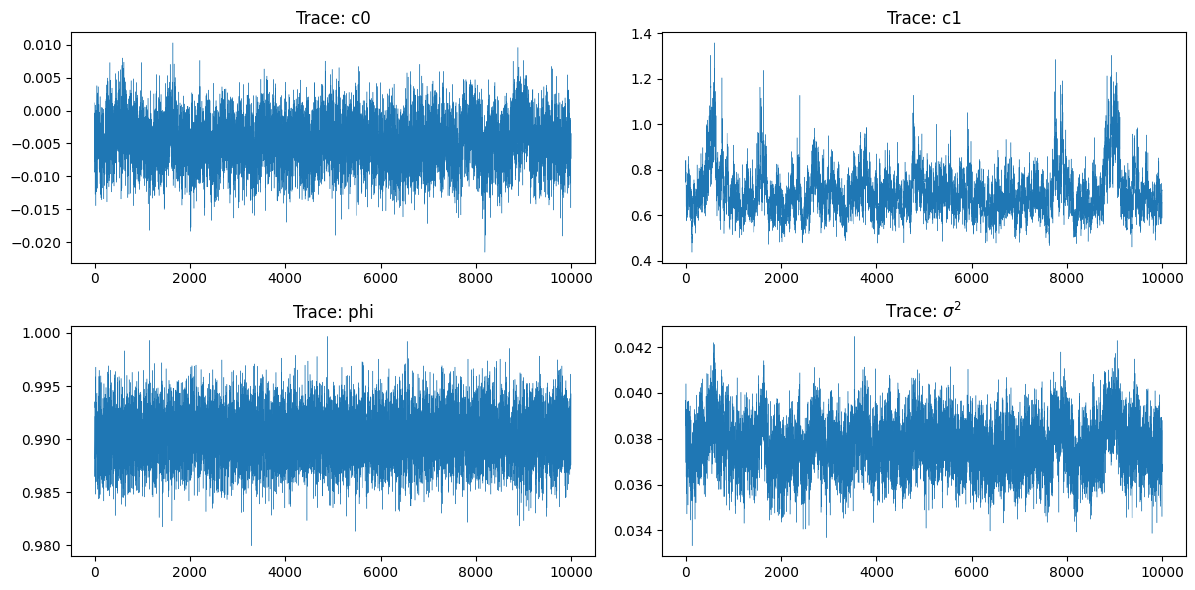

In [91]:
# --- Trace plots ---
theta_names = ['c0', 'c1', 'phi']

fig, axes = plt.subplots(2, 2, figsize=(12, 6))
for j, (ax, name) in enumerate(zip(axes.flat[:3], theta_names)):
    ax.plot(draws['theta'][:, j], linewidth=0.3)
    ax.set_title(f'Trace: {name}')
axes[1, 1].plot(draws['sigma2'], linewidth=0.3)
axes[1, 1].set_title(r'Trace: $\sigma^2$')
plt.tight_layout()
plt.show()

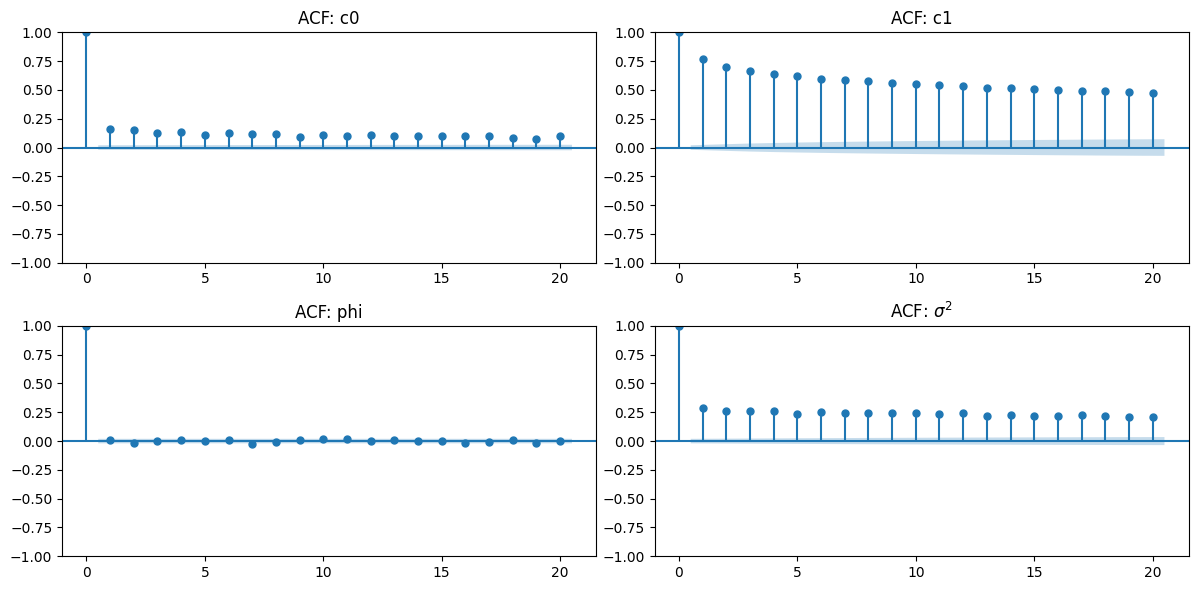

In [92]:
# --- Autocorrelation ---
fig, axes = plt.subplots(2, 2, figsize=(12, 6))
for j, (ax, name) in enumerate(zip(axes.flat[:3], theta_names)):
    plot_acf(draws['theta'][:, j], lags=20, ax=ax, title=f'ACF: {name}')
plot_acf(draws['sigma2'], lags=20, ax=axes[1, 1], title=r'ACF: $\sigma^2$')
plt.tight_layout()
plt.show()

In [93]:
# --- Geweke convergence test ---
def geweke_test(chain, frac1=0.1, frac2=0.5):
    """Geweke (1992) test for stationarity of MCMC chain."""
    n = len(chain)
    a = chain[:int(frac1 * n)]
    b = chain[int((1 - frac2) * n):]
    diff = a.mean() - b.mean()
    se = np.sqrt(a.var() / len(a) + b.var() / len(b))
    z = diff / se if se > 0 else 0.0
    return z, 2 * norm.sf(abs(z))

print(f'{"parameter":<20s} {"z-stat":>8s} {"p-value":>8s}')
print('-' * 38)
for j, name in enumerate(theta_names):
    z, p = geweke_test(draws['theta'][:, j])
    print(f'{name:<20s} {z:8.3f} {p:8.3f}')
z, p = geweke_test(draws['sigma2'])
print(f'{"sigma2":<20s} {z:8.3f} {p:8.3f}')
for j, name in enumerate(col_names):
    z, p = geweke_test(draws['alpha'][:, j])
    print(f'{"alpha: " + name:<20s} {z:8.3f} {p:8.3f}')

parameter              z-stat  p-value
--------------------------------------
c0                      7.373    0.000
c1                     11.125    0.000
phi                    -1.739    0.082
sigma2                  8.714    0.000
alpha: intercept      -12.582    0.000
alpha: soil_moisture_28_to_100cm_mean_central_illinois_roll30d_min    0.151    0.880
alpha: soil_moisture_0_to_100cm_mean_parana_roll30d_min   11.490    0.000
alpha: precipitation_sum_central_indiana_roll30d_sum   -3.007    0.003
alpha: temperature_2m_mean_mato_grosso_roll30d_mean   -1.804    0.071
alpha: vapour_pressure_deficit_max_mato_grosso_roll30d_mean    3.240    0.001


## 7. Posterior results

In [73]:
def hpdi(chain, prob=0.95):
    """Highest posterior density interval."""
    sorted_chain = np.sort(chain)
    n = len(sorted_chain)
    interval_size = int(np.ceil(prob * n))
    widths = sorted_chain[interval_size:] - sorted_chain[:n - interval_size]
    best = np.argmin(widths)
    return sorted_chain[best], sorted_chain[best + interval_size]

def summary_table(draws_dict, theta_names, alpha_names):
    """Print a posterior summary table."""
    rows = []
    # theta
    for j, name in enumerate(theta_names):
        chain = draws_dict['theta'][:, j]
        lo, hi = hpdi(chain)
        rows.append([name, chain.mean(), chain.std(), np.median(chain), lo, hi])
    # sigma2
    chain = draws_dict['sigma2']
    lo, hi = hpdi(chain)
    rows.append(['sigma2', chain.mean(), chain.std(), np.median(chain), lo, hi])
    # alpha
    for j, name in enumerate(alpha_names):
        chain = draws_dict['alpha'][:, j]
        lo, hi = hpdi(chain)
        rows.append([f'alpha: {name}', chain.mean(), chain.std(), np.median(chain), lo, hi])

    print(f'{"parameter":<30s} {"mean":>10s} {"std":>10s} {"median":>10s} {"95% lo":>10s} {"95% hi":>10s}')
    print('-' * 82)
    for r in rows:
        print(f'{r[0]:<30s} {r[1]:10.4f} {r[2]:10.4f} {r[3]:10.4f} {r[4]:10.4f} {r[5]:10.4f}')

summary_table(draws, theta_names, col_names)

parameter                            mean        std     median     95% lo     95% hi
----------------------------------------------------------------------------------
c0                                -0.0009     0.0040    -0.0008    -0.0088     0.0067
c1                                 0.0038     0.0044     0.0035    -0.0046     0.0128
phi                                0.9901     0.0025     0.9901     0.9853     0.9952
sigma2                             0.0415     0.0010     0.0415     0.0395     0.0436
alpha: intercept                   4.5540     1.8298     5.1270     0.1866     6.9326
alpha: soil_moisture_28_to_100cm_mean_central_illinois_roll30d_min    12.2923     2.8517    13.2583     6.4255    16.5298
alpha: soil_moisture_0_to_100cm_mean_parana_roll30d_min    -0.3930     0.6599    -0.4557    -1.5594     1.0263
alpha: precipitation_sum_central_indiana_roll30d_sum     2.2524     2.6184     2.3317    -2.0127     6.7353
alpha: temperature_2m_mean_mato_grosso_roll30d_mean     6.00

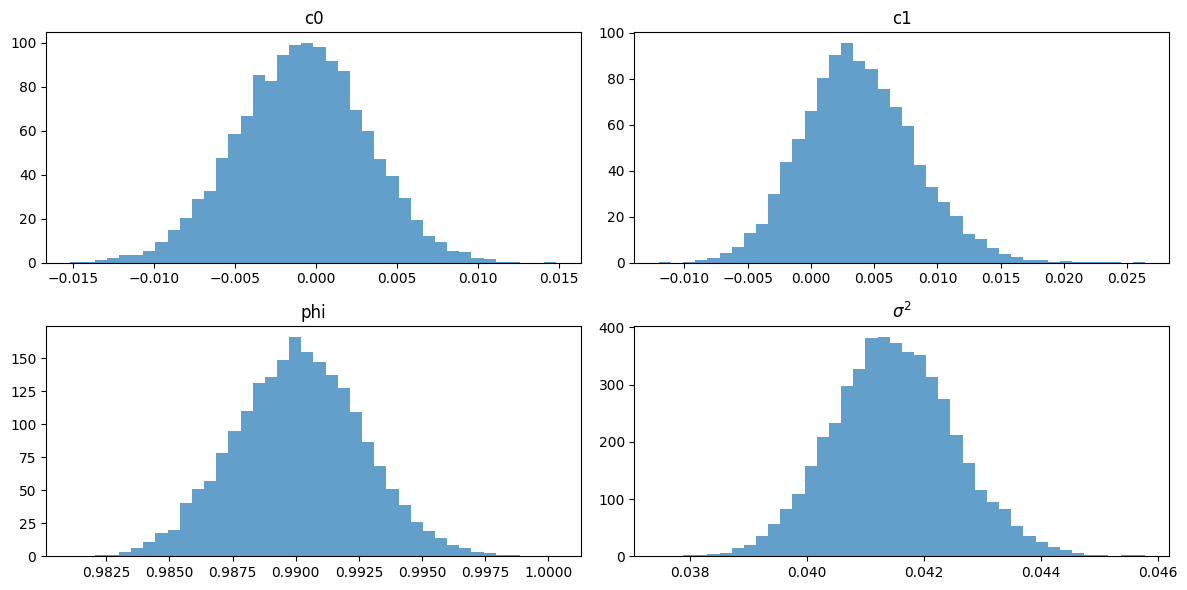

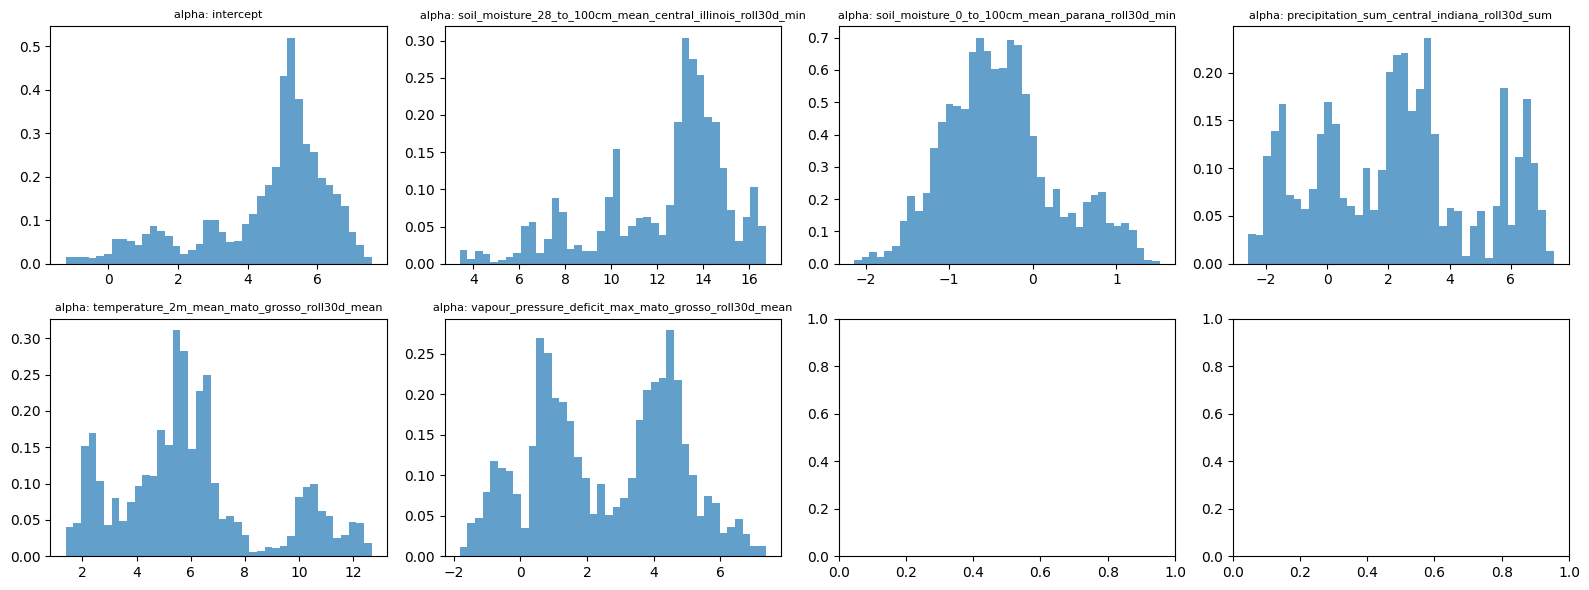

In [74]:
# --- Posterior histograms ---
fig, axes = plt.subplots(2, 2, figsize=(12, 6))
for j, (ax, name) in enumerate(zip(axes.flat[:3], theta_names)):
    ax.hist(draws['theta'][:, j], bins=40, density=True, alpha=0.7)
    ax.set_title(name)
axes[1, 1].hist(draws['sigma2'], bins=40, density=True, alpha=0.7)
axes[1, 1].set_title(r'$\sigma^2$')
plt.tight_layout()
plt.show()

# alpha histograms
n_alpha = len(col_names)
ncols_plot = min(4, n_alpha)
nrows_plot = int(np.ceil(n_alpha / ncols_plot))
fig, axes = plt.subplots(nrows_plot, ncols_plot, figsize=(4 * ncols_plot, 3 * nrows_plot))
axes_flat = np.atleast_1d(axes).flat
for j, (ax, name) in enumerate(zip(axes_flat, col_names)):
    ax.hist(draws['alpha'][:, j], bins=40, density=True, alpha=0.7)
    ax.set_title(f'alpha: {name}', fontsize=8)
plt.tight_layout()
plt.show()

## 8. Regime probabilities

$E[s_t \mid y]$ — posterior probability that time $t$ is in regime 1 (high spread / soy-stressed).

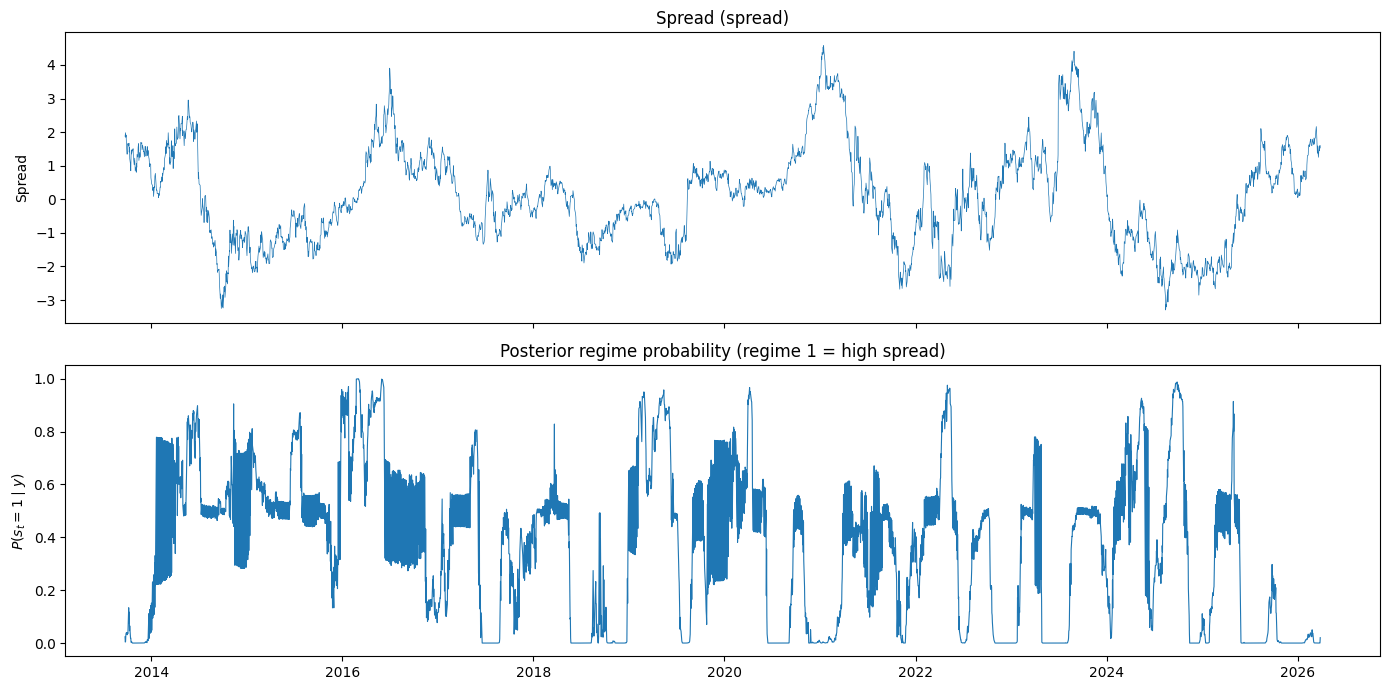

In [75]:
# align regime probabilities with the date index
sub = df[[spread_col] + weather_cols].dropna()
dates = sub.index[1:]   # first obs lost to the lag

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 7), sharex=True)

ax1.plot(dates, y, linewidth=0.5)
ax1.set_ylabel('Spread')
ax1.set_title(f'Spread ({spread_col})')

ax2.plot(dates, draws['regime_prob'], linewidth=0.8)
ax2.set_ylabel(r'$P(s_t = 1 \mid y)$')
ax2.set_title('Posterior regime probability (regime 1 = high spread)')
ax2.set_ylim(-0.05, 1.05)

plt.tight_layout()
plt.show()

In [76]:
# --- Derived quantities ---
# Half-life of mean reversion
phi_draws = draws['theta'][:, 2]
half_life = -np.log(2) / np.log(np.abs(phi_draws))
print(f'Half-life of mean reversion (trading days):')
lo, hi = hpdi(half_life)
print(f'  mean = {half_life.mean():.1f},  median = {np.median(half_life):.1f},  95% HPDI = [{lo:.1f}, {hi:.1f}]')

# Unconditional regime-0 and regime-1 means: c / (1 - phi)
c0_draws = draws['theta'][:, 0]
c1_draws = draws['theta'][:, 1]
mu0 = c0_draws / (1 - phi_draws)
mu1 = c1_draws / (1 - phi_draws)
print(f'\nUnconditional spread mean in regime 0 (corn-stressed):')
lo, hi = hpdi(mu0)
print(f'  mean = {mu0.mean():.3f},  95% HPDI = [{lo:.3f}, {hi:.3f}]')
print(f'Unconditional spread mean in regime 1 (soy-stressed):')
lo, hi = hpdi(mu1)
print(f'  mean = {mu1.mean():.3f},  95% HPDI = [{lo:.3f}, {hi:.3f}]')

Half-life of mean reversion (trading days):
  mean = 75.7,  median = 69.9,  95% HPDI = [42.0, 122.3]

Unconditional spread mean in regime 0 (corn-stressed):
  mean = -0.112,  95% HPDI = [-1.128, 0.715]
Unconditional spread mean in regime 1 (soy-stressed):
  mean = 0.404,  95% HPDI = [-0.563, 1.540]


## 9. (Optional) Repeat with Kalman spread

Change `spread_col` and re-run Sections 3–8 to compare.

In [17]:
# --- Uncomment to run with Kalman spread ---
spread_col = 'kf_spread'
y_kf, y_lag_kf, W_kf, col_names_kf = prepare_regime_data(
    df, spread_col, weather_cols, standardize_weather=True
)
draws_kf = gibbs_regime_switching(
    y_kf, y_lag_kf, W_kf,
    nos=nos, nob=nob, nod=nod,
    prior_alpha_mean=prior_alpha_mean, prior_alpha_var=prior_alpha_var,
    prior_theta_mean=prior_theta_mean, prior_theta_var=prior_theta_var,
    seed=seed,
)
# Then use draws_kf in the diagnostic and results cells above.

  iteration 0 / 22000
  iteration 5000 / 22000


/Users/wiktor/TIC/Spring2026-TIC/Ensemble_Wiktor/notebooks/../src/regime.py:173: RuntimeWarning: overflow encountered in exp
  prob = 1.0 / (1.0 + np.exp(log_omega0 - log_omega1))


  iteration 10000 / 22000
  iteration 15000 / 22000
  iteration 20000 / 22000
